In [2]:
import math, copy
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x,plt_contour_wgrad,plt_divergence,plt_gradients

In [ ]:
# Load our dataset
x_train=np.array([1.0,2.0]) # features
y_train=np.array([300.0,500.0]) # targets

In [5]:
# Function to calculate the cost
def compute_cost(x,y,w,b):

    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost += f_wb
    total_cost = ( 1 / (2 * m) ) * cost

    return total_cost

In [6]:
def compute_gradient(x,y,w,b):
    """
    Computes the gradient for linear regression

    Args:
         x (ndarray (m,)): Data, m examples 
         y (ndarray (m,)): Target values
         w, b (scalar)   : model parameters
    Returns
        dj_dw (scalar): The gradient of the cost w.r.t. the parameter w          
        dj_db (scalar): The gradient of the cost w.r.t. the parameter b          
    """

    # Number of training examples
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i]) 
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw , dj_db

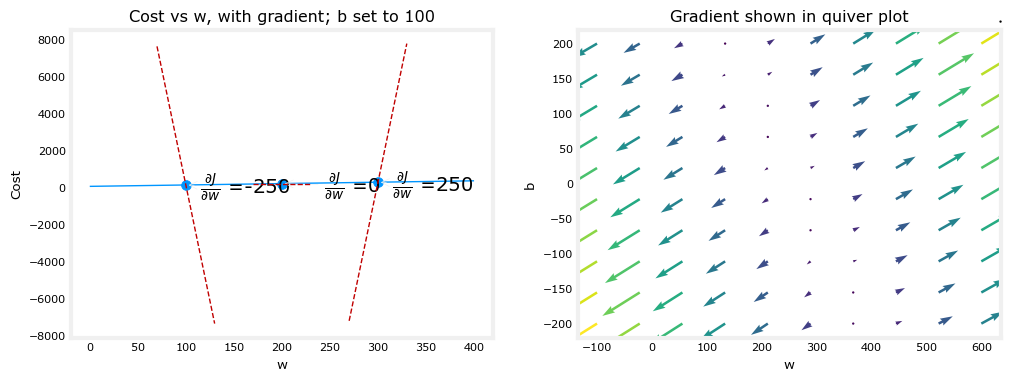

In [8]:
plt_gradients(x_train,y_train,compute_cost,compute_gradient)

In [12]:
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,gradient_function):
    """
    Performs gradient descent to fit w,b. Updates wmb by taking
    num_iters gradients steps with learning rate alpha.
    Args:
        x (ndarray (m,))  : Data, m examples 
        y (ndarray (m,))  : target values
        w_in,b_in (scalar): initial values of model parameters  
        alpha (float):     Learning rate
        num_iters (int):   number of iterations to run gradient descent
        cost_function:     function to call to produce cost
        gradient_function: function to call to produce gradient
        
    Returns:
        w (scalar): Updated value of parameter after running gradient descent
        b (scalar): Updated value of parameter after running gradient descent
        J_history (List): History of cost values
        p_history (list): History of parameters [w,b] 
    """

    # An array to store cost J and w's at each iteration 
    # primaryly for graphing later
    J_history=[]
    p_history=[]
    b=b_in
    w=w_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        # using gardient_function
        dj_dw, dj_db = gradient_function(x,y,w,b)

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        # Save cost J at each iteration
        if i < 100000: # Prevent resource exhaustion
            J_history.append(cost_function(x,y,w,b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many 
        # iterations if < 10
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e}",
            f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}",
            f"w: {w:0.3e}, b: {b:0.3e}")    
    return w, b, J_history, p_history #return w and J,w history for graphing

In [13]:
# Initialize parameters
w_init=0
b_init=0
# Some gradient descent settings
iterations=10000
tmp_aplha=1.0e-2
# Run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train,
y_train,w_init,b_init,tmp_aplha,iterations,compute_cost,
compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 6.88e+00 dj_dw: -6.500e+02, dj_db: -4.000e+02 w: 6.500e+00, b: 4.000e+00
Iteration 1000: Cost 2.00e+02 dj_dw: -3.712e-01, dj_db:  6.007e-01 w: 1.949e+02, b: 1.082e+02
Iteration 2000: Cost 2.00e+02 dj_dw: -1.789e-01, dj_db:  2.895e-01 w: 1.975e+02, b: 1.040e+02
Iteration 3000: Cost 2.00e+02 dj_dw: -8.625e-02, dj_db:  1.396e-01 w: 1.988e+02, b: 1.019e+02
Iteration 4000: Cost 2.00e+02 dj_dw: -4.158e-02, dj_db:  6.727e-02 w: 1.994e+02, b: 1.009e+02
Iteration 5000: Cost 2.00e+02 dj_dw: -2.004e-02, dj_db:  3.243e-02 w: 1.997e+02, b: 1.004e+02
Iteration 6000: Cost 2.00e+02 dj_dw: -9.660e-03, dj_db:  1.563e-02 w: 1.999e+02, b: 1.002e+02
Iteration 7000: Cost 2.00e+02 dj_dw: -4.657e-03, dj_db:  7.535e-03 w: 1.999e+02, b: 1.001e+02
Iteration 8000: Cost 2.00e+02 dj_dw: -2.245e-03, dj_db:  3.632e-03 w: 2.000e+02, b: 1.000e+02
Iteration 9000: Cost 2.00e+02 dj_dw: -1.082e-03, dj_db:  1.751e-03 w: 2.000e+02, b: 1.000e+02
(w,b) found by gradient descent: (199.9929,100.0116)


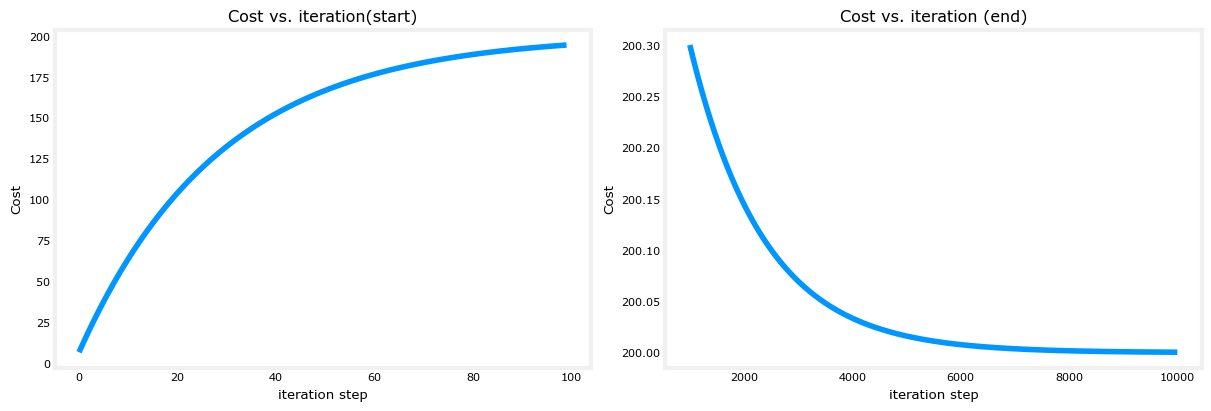

In [14]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [16]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars


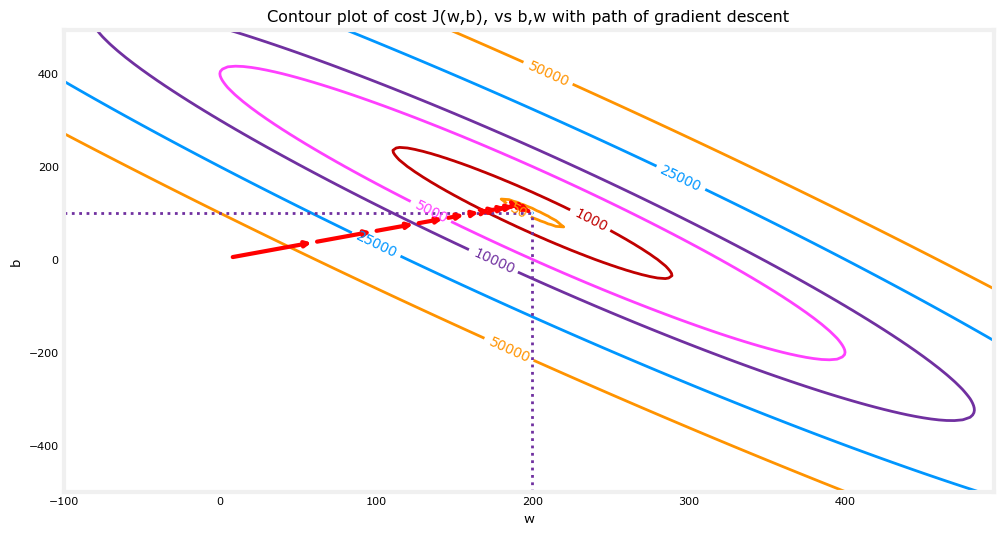

In [17]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

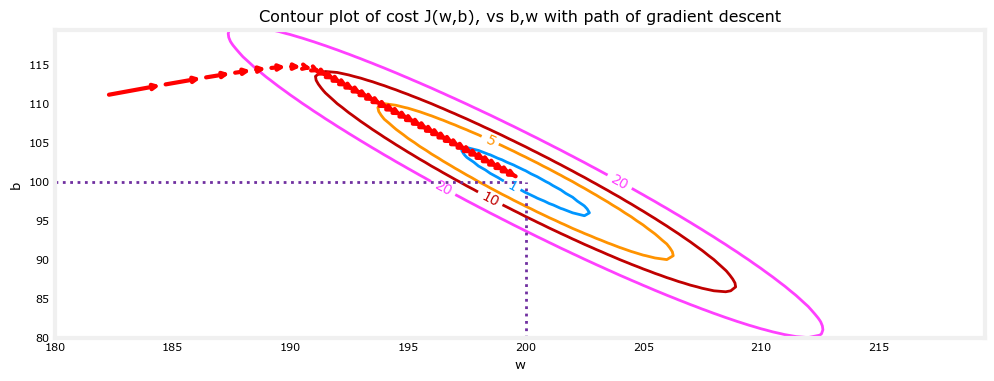

In [18]:
fig, ax = plt.subplots(1,1, figsize=(12, 4))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range=[180, 220, 0.5], b_range=[80, 120, 0.5],
            contours=[1,5,10,20],resolution=0.5)

In [19]:
# initialize parameters
w_init = 0
b_init = 0
# set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 5.50e+02 dj_dw: -6.500e+02, dj_db: -4.000e+02 w: 5.200e+02, b: 3.200e+02
Iteration    1: Cost -4.08e+02 dj_dw:  1.130e+03, dj_db:  7.000e+02 w: -3.840e+02, b: -2.400e+02
Iteration    2: Cost 1.26e+03 dj_dw: -1.970e+03, dj_db: -1.216e+03 w: 1.192e+03, b: 7.328e+02
Iteration    3: Cost -1.65e+03 dj_dw:  3.429e+03, dj_db:  2.121e+03 w: -1.551e+03, b: -9.638e+02
Iteration    4: Cost 3.42e+03 dj_dw: -5.974e+03, dj_db: -3.691e+03 w: 3.228e+03, b: 1.989e+03
Iteration    5: Cost -5.40e+03 dj_dw:  1.040e+04, dj_db:  6.431e+03 w: -5.095e+03, b: -3.156e+03
Iteration    6: Cost 9.95e+03 dj_dw: -1.812e+04, dj_db: -1.120e+04 w: 9.402e+03, b: 5.802e+03
Iteration    7: Cost -1.68e+04 dj_dw:  3.156e+04, dj_db:  1.950e+04 w: -1.584e+04, b: -9.801e+03
Iteration    8: Cost 2.98e+04 dj_dw: -5.496e+04, dj_db: -3.397e+04 w: 2.813e+04, b: 1.737e+04
Iteration    9: Cost -5.13e+04 dj_dw:  9.572e+04, dj_db:  5.916e+04 w: -4.845e+04, b: -2.996e+04


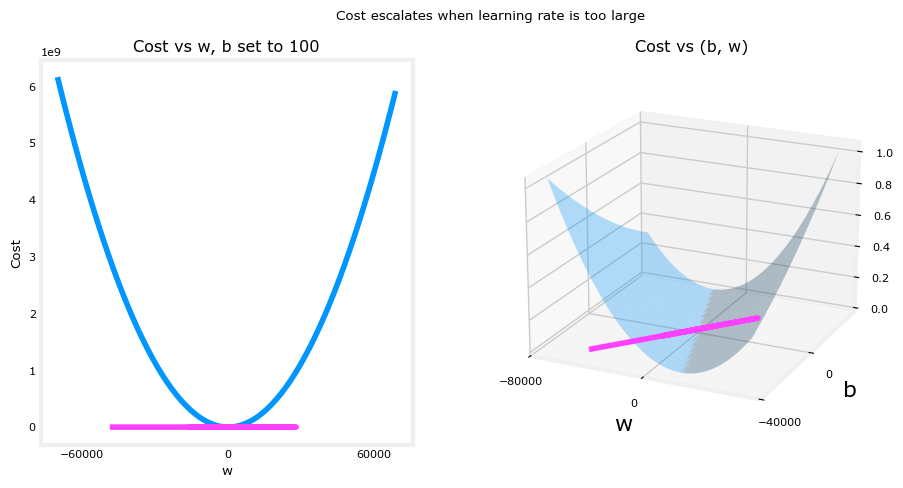

In [20]:
plt_divergence(p_hist, J_hist,x_train, y_train)
plt.show()